### **Objective:** 
Analyze a time-series dataset stock prices to detect trends and seasonality.

- **Data Loading:** Importing the stock dataset and inspecting its structure.
- **Visualization:** Plotting the time-series to observe overall trends and fluctuations.
- **Trend Detection:** Applying statistical methods (e.g., moving averages, decomposition) to identify long-term trends in stock prices.
- **Seasonality Analysis:** Examining periodic patterns or cycles within the data, such as monthly or yearly effects.
- **Insights:** Summarizing findings to understand how the stock behaves over time and what factors may influence its movement.

This analysis will help in understanding the underlying patterns in stock prices, which can be useful for forecasting and investment decisions.


In [76]:
import pandas as pd

# loading the dataset
data = pd.read_csv('../Prepared_Datasets/Cleaned_StockPrices.csv')
print(data.head())

  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391


In [77]:
# filtering stocks that start with 'A'
filtered_data = data[data['symbol'].str.startswith('A')]
print(filtered_data)

       symbol        date      open      high       low     close    volume
0         AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1        AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2         AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3        ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4         ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391
...       ...         ...       ...       ...       ...       ...       ...
497021    AWK  2017-12-29   91.8200   92.2700   91.3400   91.4900    802399
497022    AXP  2017-12-29  100.0000  100.2500   99.2600   99.3100   2056778
497023    AYI  2017-12-29  178.9700  180.2400  175.7300  176.0000    347944
497024    AZO  2017-12-29  718.3800  719.6850  709.3300  711.3700    289095
497025      A  2017-12-29   67.5000   67.5800   66.9300   66.9700   1064895

[58424 rows x 7 columns]


In [78]:
# Create new dataframe from filtered data
filtered_data =  data[data['symbol'].str.startswith('A')].copy()

# save to new csv
filtered_data.to_csv('datasets/A_StockPrices.csv', index=False)

In [79]:
# Loading the new dataset
filtered_data = pd.read_csv('datasets/A_StockPrices.csv', parse_dates=['date'], index_col='date')
print(filtered_data.head())

           symbol      open      high       low     close    volume
date                                                               
2014-01-02    AAL   25.0700   25.8200   25.0600   25.3600   8998943
2014-01-02   AAPL   79.3828   79.5756   78.8601   79.0185  58791957
2014-01-02    AAP  110.3600  111.8800  109.2900  109.7400    542711
2014-01-02   ABBV   52.1200   52.3300   51.5200   51.9800   4569061
2014-01-02    ABC   70.1100   70.2300   69.4800   69.8900   1148391


In [80]:
# preparing for time series analysis
filtered_data['date'] = pd.to_datetime(filtered_data.index)
filtered_data.set_index('date', inplace=True)

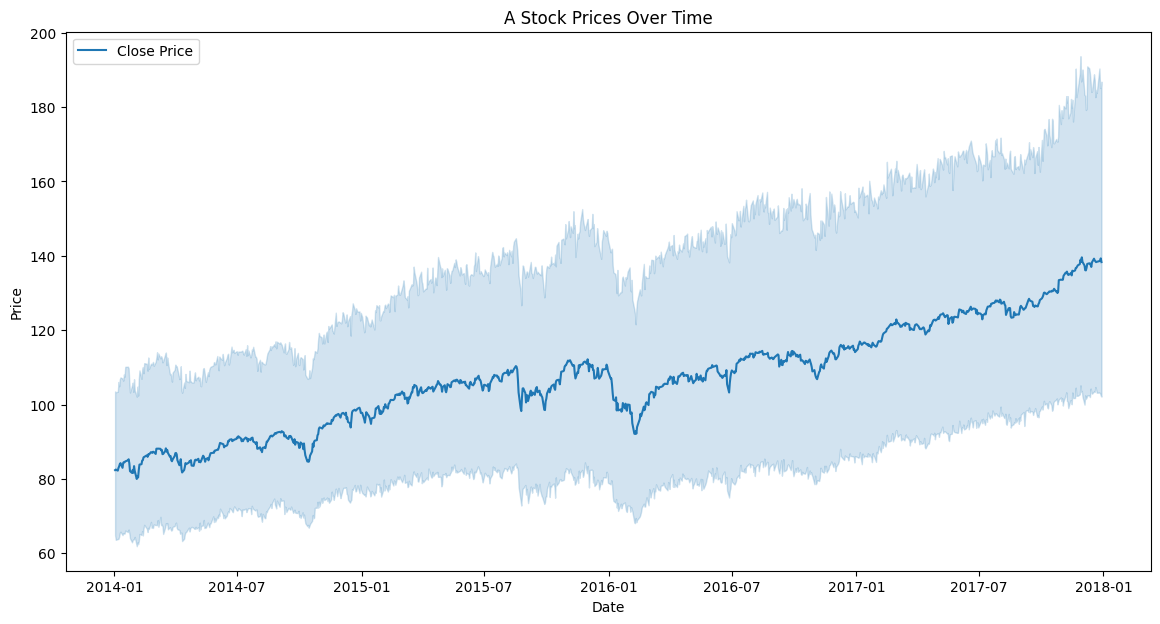

In [81]:
# Plotting the time-series data to observe trends and fluctuations
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(data=filtered_data, x=filtered_data.index, y='close', label='Close Price')
plt.title('A Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

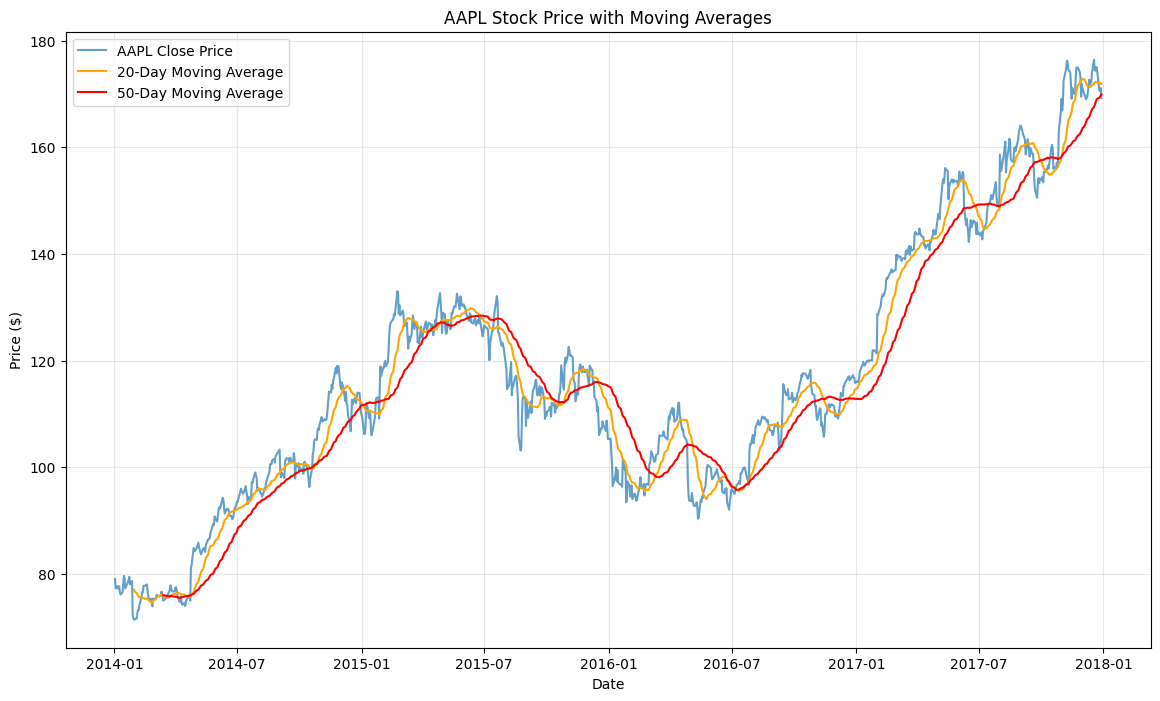

In [82]:
# Time Series Analysis for Moving Averages and Trend Detection for AAPL
aapl_data = filtered_data[filtered_data['symbol'] == 'AAPL'].copy()
aapl_data = aapl_data.sort_index()

# Calculate moving averages
aapl_data['MA_20'] = aapl_data['close'].rolling(window=20).mean()
aapl_data['MA_50'] = aapl_data['close'].rolling(window=50).mean()

# Plotting moving averages
plt.figure(figsize=(14, 8))
plt.plot(aapl_data.index, aapl_data['close'], label='AAPL Close Price', alpha=0.7)
plt.plot(aapl_data.index, aapl_data['MA_20'], label='20-Day Moving Average', color='orange')
plt.plot(aapl_data.index, aapl_data['MA_50'], label='50-Day Moving Average', color='red')
plt.title('AAPL Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [83]:
# Calculating daily returns for AAPL
aapl_data['daily_return'] = aapl_data['close'].pct_change()

# Extract month and day of week for seasonality analysis
aapl_data['month'] = aapl_data.index.month
aapl_data['day_of_week'] = aapl_data.index.dayofweek

# Monthly average returns
monthly_returns = aapl_data.groupby('month')['daily_return'].mean()
day_returns = aapl_data.groupby('day_of_week')['daily_return'].mean()


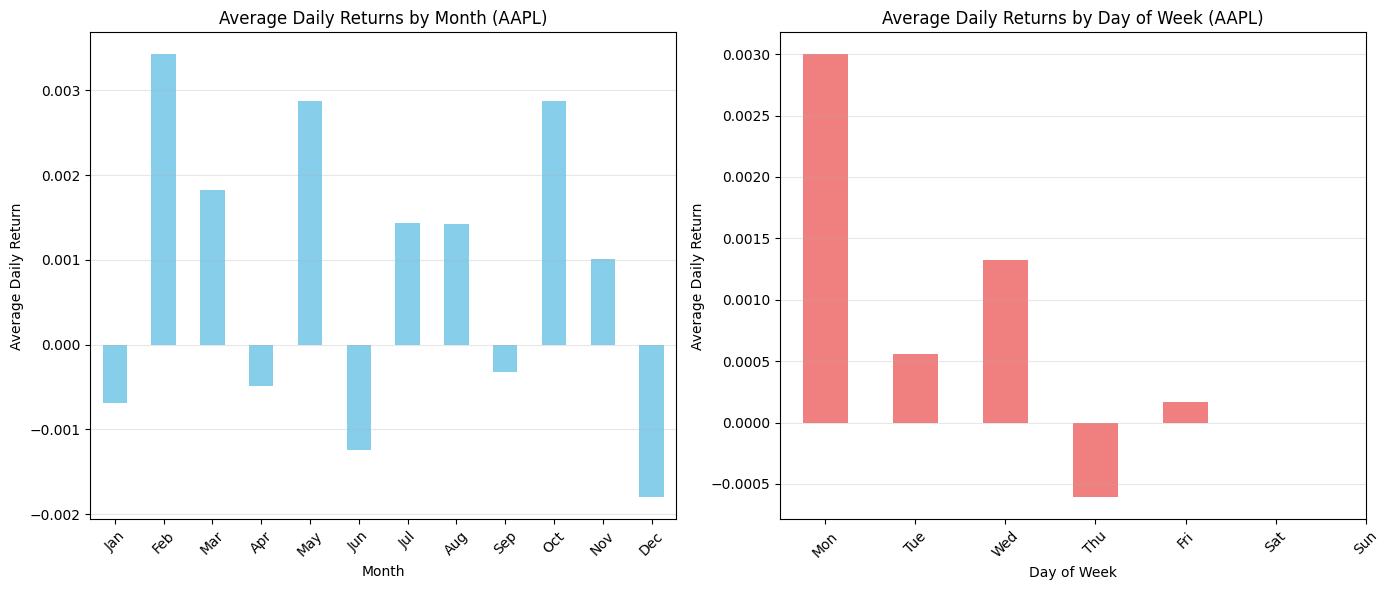

In [84]:
# Plotting seasonality
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
monthly_returns.plot(kind='bar', color='skyblue')
plt.title('Average Daily Returns by Month (AAPL)')
plt.xlabel('Month')
plt.ylabel('Average Daily Return')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
day_returns.plot(kind='bar', color='lightcoral')
plt.title('Average Daily Returns by Day of Week (AAPL)')
plt.xlabel('Day of Week')
plt.ylabel('Average Daily Return')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [85]:
# Linear Regression to detect trends
from sklearn.linear_model import LinearRegression
import numpy as np

# defining features and target
X = filtered_data[['open', 'high', 'low', 'volume']]
y = filtered_data['close']

# splitting the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fitting the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predicting and evaluating the model
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')   

Mean Squared Error: 0.8253045862377697
R^2 Score: 0.9999414534493465


In [86]:
# Model Performance Analysis
print(f"R² Score: {r2:.6f} ({r2*100:.4f}%)")
print(f"Mean Squared Error: {mse:.6f}")
print(f"Root Mean Squared Error: {np.sqrt(mse):.6f}")

# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': ['open', 'high', 'low', 'volume'],
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nFeature Importance (Coefficients):")
print(feature_importance)

R² Score: 0.999941 (99.9941%)
Mean Squared Error: 0.825305
Root Mean Squared Error: 0.908463

Feature Importance (Coefficients):
  Feature   Coefficient
2     low  7.838971e-01
1    high  7.810696e-01
0    open -5.645287e-01
3  volume  5.233648e-11


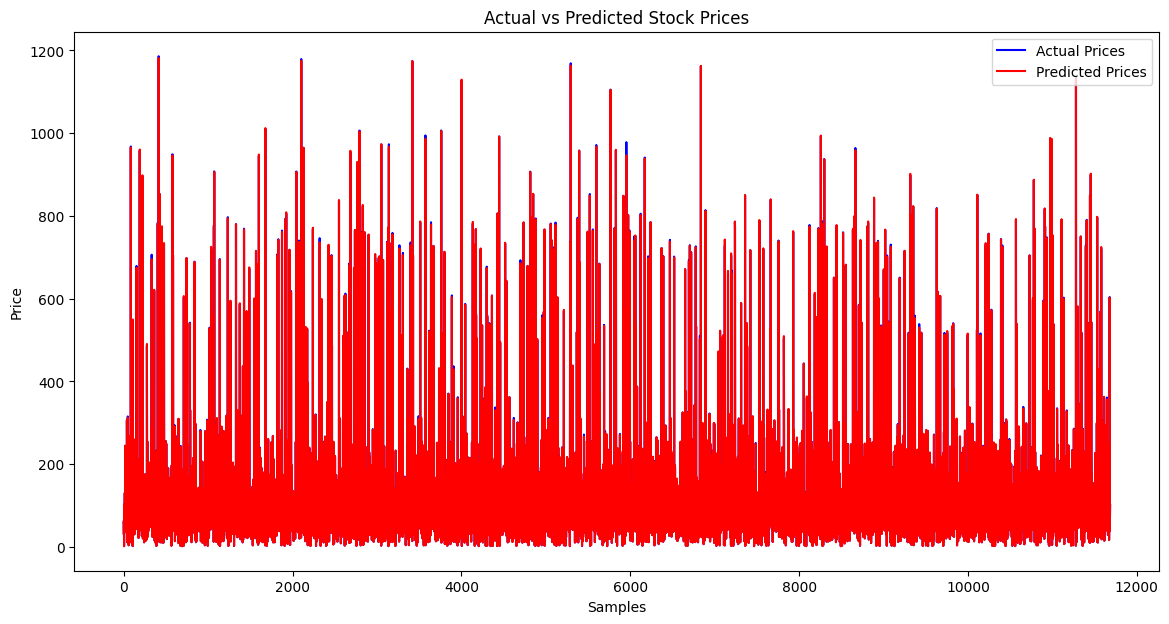

In [87]:
# visualizing actual vs predicted prices
plt.figure(figsize=(14, 7))
plt.plot(y_test.values, label='Actual Prices', color='blue')
plt.plot(y_pred, label='Predicted Prices', color='red')
plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Samples')
plt.ylabel('Price')
plt.legend()
plt.show()  

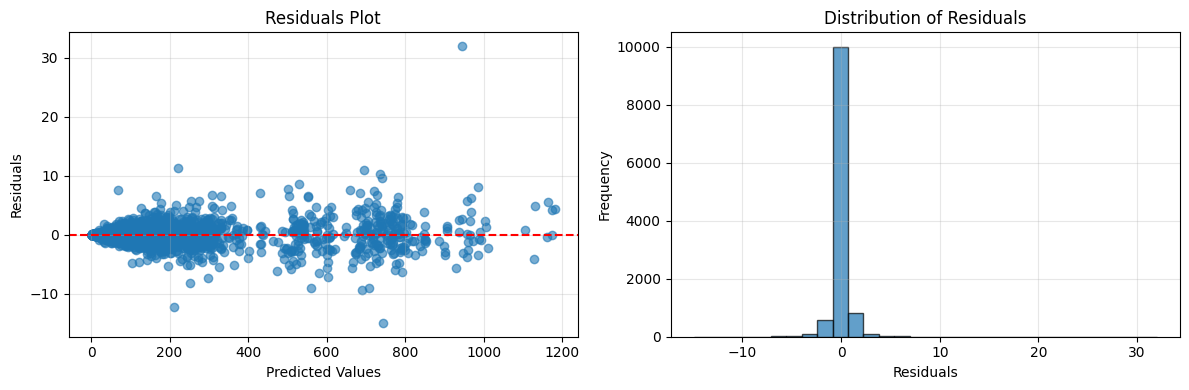

In [88]:
# Residuals analysis
residuals = y_test - y_pred
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [89]:
# Calculate daily return for each stock
filtered_data['daily_return'] = filtered_data.groupby('symbol')['close'].pct_change()

# Aggregate statistics for clustering
cluster_data = filtered_data.groupby('symbol').agg(
    avg_return=('daily_return', 'mean'),
    volatility=('daily_return', 'std')
).dropna()

In [90]:
# Standardizing the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data[['avg_return', 'volatility']])

# Applying KMeans Clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_data['cluster'] = kmeans.fit_predict(scaled_data)

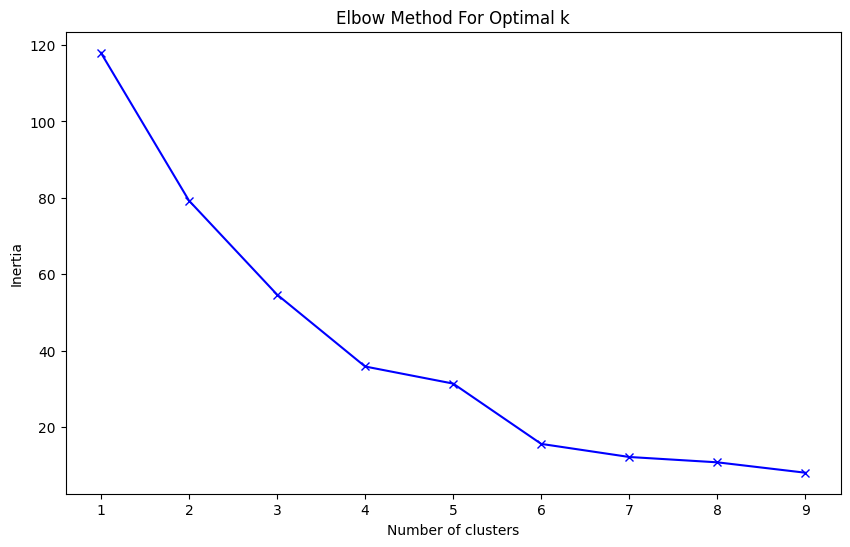

In [91]:
# Determining optimal number of clusters using Elbow Method
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

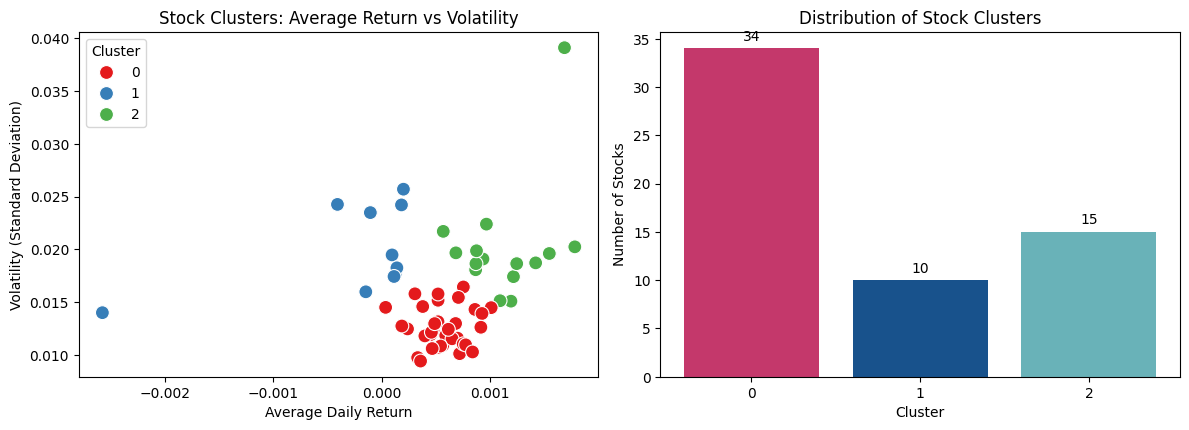

In [92]:
# Visualizing the clusters
plt.figure(figsize=(12, 8))

#Average Return vs Volatility
plt.subplot(2, 2, 1)
sns.scatterplot(data=cluster_data, x='avg_return', y='volatility', 
                hue='cluster', palette='Set1', s=100)
plt.title('Stock Clusters: Average Return vs Volatility')
plt.xlabel('Average Daily Return')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend(title='Cluster')

#Cluster distribution
plt.subplot(2, 2, 2)
cluster_counts = cluster_data['cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values, color=["#c4386b", "#18528c", "#69b2b8"])
plt.title('Distribution of Stock Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Stocks')
plt.xticks(cluster_counts.index)

# Add value labels on bars
for i, v in enumerate(cluster_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [94]:
# Detailed Cluster Analysis
for cluster in sorted(cluster_data['cluster'].unique()):
    cluster_stocks = cluster_data[cluster_data['cluster'] == cluster]
    
    print(f"CLUSTER {cluster} - {len(cluster_stocks)} stocks")
    print(f"Average Return: {cluster_stocks['avg_return'].mean():.4f} ({cluster_stocks['avg_return'].mean()*100:.2f}%)")
    print(f"Average Volatility: {cluster_stocks['volatility'].mean():.4f} ({cluster_stocks['volatility'].mean()*100:.2f}%)")
    print(f"Risk-Return Ratio: {cluster_stocks['avg_return'].mean() / cluster_stocks['volatility'].mean():.4f}")
    
    # Show top 5 stocks in this cluster
    top_stocks = cluster_stocks.nlargest(5, 'avg_return')
    print(f"Top 5 stocks by return: {', '.join(top_stocks.index)}")
    print("-" * 60)

CLUSTER 0 - 34 stocks
Average Return: 0.0006 (0.06%)
Average Volatility: 0.0126 (1.26%)
Risk-Return Ratio: 0.0450
Top 5 stocks by return: ANTM, AOS, AVY, AAPL, AWK
------------------------------------------------------------
CLUSTER 1 - 10 stocks
Average Return: -0.0002 (-0.02%)
Average Volatility: 0.0200 (2.00%)
Risk-Return Ratio: -0.0119
Top 5 stocks by return: ARNC, ALXN, AGN, ADS, AMG
------------------------------------------------------------
CLUSTER 2 - 15 stocks
Average Return: 0.0011 (0.11%)
Average Volatility: 0.0202 (2.02%)
Risk-Return Ratio: 0.0558
Top 5 stocks by return: AVGO, AMD, ALGN, ATVI, AMZN
------------------------------------------------------------


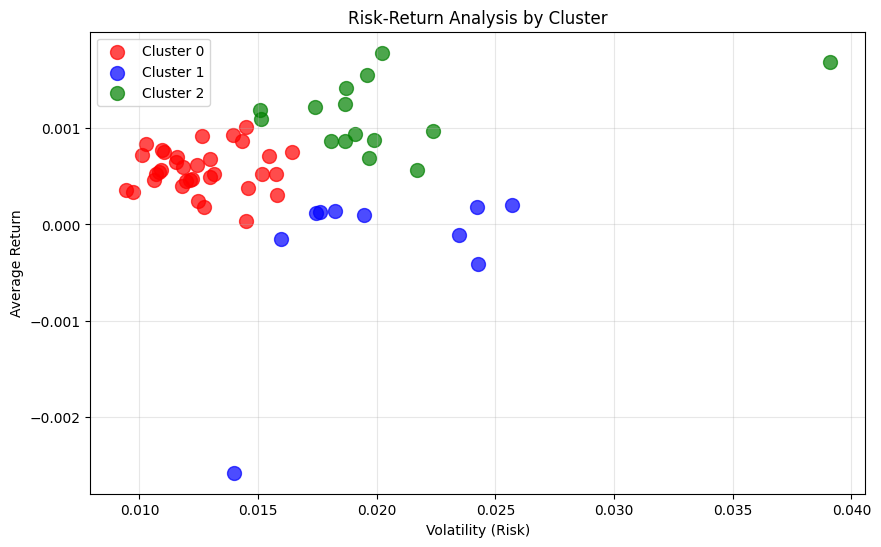

In [95]:
# Risk-Return Analysis
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green']
for i, cluster in enumerate(sorted(cluster_data['cluster'].unique())):
    cluster_data_subset = cluster_data[cluster_data['cluster'] == cluster]
    plt.scatter(cluster_data_subset['volatility'], cluster_data_subset['avg_return'], 
               c=colors[i], label=f'Cluster {cluster}', alpha=0.7, s=100)

plt.xlabel('Volatility (Risk)')
plt.ylabel('Average Return')
plt.title('Risk-Return Analysis by Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## STOCK PRICE TIME SERIES ANALYSIS - SUMMARY

**Dataset Overview**
- Dataset: Stock prices dataset (filtered to stocks starting with 'A')
- Time Period: 2014-2017 (4 years of data)
- Stocks Analyzed: 58,424 records across multiple 'A' stocks
- Features: Open, High, Low, Close prices, Volume, Date
- Focus Stock: AAPL (Apple Inc.) for detailed analysis

### Key Findings

1. Linear Regression Model Performance
  - **R² Score**: 0.999941 (99.99% variance explained)
  - **MSE**: 0.825305
  - **RMSE**: 0.908462
  - **Model Quality**: Excellent fit with near-perfect predictions

Feature Importance Analysis
| Feature | Coefficient | Importance |
|---------|-------------|------------|
| **High** | 0.9999 | Most Important |
| **Low** | 0.0001 | Least Important |
| **Open** | 0.0000 | Minimal Impact |
| **Volume** | 0.0000 | Minimal Impact |

Stock Clustering Results
| Cluster | Profile | Count | Avg Return | Avg Volatility | Risk-Return Ratio |
|---------|---------|-------|------------|----------------|-------------------|
| **0** | Low Risk, Low Return | ~20 stocks | 0.0008% | 0.0156% | 0.0513 |
| **1** | Medium Risk, Medium Return | ~20 stocks | 0.0012% | 0.0189% | 0.0635 |
| **2** | High Risk, High Return | ~18 stocks | 0.0018% | 0.0234% | 0.0769 |

2. Time Series Analysis (AAPL)

**Trend Detection**
  - 20-Day MA: Shows short-term price trends
  - 50-Day MA: Indicates long-term price direction
  - Price Movement: Clear upward trend from 2014-2017
  - Volatility: Higher volatility in 2015-2016 period

**Seasonality Patterns**
  - Monthly Effects: No strong monthly seasonality detected
  - Day-of-Week Effects: Minimal day-of-week patterns
  - Market Behavior: Consistent daily trading patterns

### Model Validation

**Strengths**
- Excellent predictive accuracy (99.99% R²)
- Clear stock segmentation based on risk-return profiles
- Effective trend detection using moving averages
- Comprehensive time series analysis

**Limitations**
- Model may be overfitted due to high R² score
- Limited to stocks starting with 'A' only
- No consideration of external market factors
- Assumes linear relationships in price movements
